# MatImba — a guided tour

**MatImba** is a distribution imbalance-aware regression framework for materials ML.
Materials property datasets are almost always imbalanced: predictive capacity
concentrates on the dense bulk of the target distribution, and errors spike exactly
where high-value materials live — in the sparse tails. MatImba works with that
reality end-to-end, in three composable stages:

| Stage | Question | Entry points |
|---|---|---|
| **1. Describe** | How imbalanced is my dataset, before any training? | `DatasetProfile`, `compare_profiles` |
| **2. Train** | How do I train and select checkpoints robustly? | `BaseRobustTrainer`, DILA loss, `matimba-train` |
| **3. Analyse** | Which model is actually better in the tail — and is tail error trainable away at all? | `MatImba.analysis`, `matimba-analyse` |

This notebook explains the **concepts** behind each stage and demonstrates the
**usage** on synthetic data (fast, self-contained) and on the archived paper
experiments. Runs top-to-bottom on CPU in a few minutes.

```bash
git clone https://github.com/Lei-Lei-alpha/MatImba.git && cd MatImba
pip install -e .
```


## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from MatImba.analysis import use_matimba_style

use_matimba_style()   # the packaged ggplot_bw style used for all MatImba figures
rng = np.random.default_rng(0)

/gpfs01/home/ezzll3/chemsoft/mace/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Concepts

### 1.1 What is imbalanced regression?

In classification, "imbalance" means unequal class counts. In **regression** there
are no classes — rarity is relative to the local probability density of the
continuous target. MatImba grounds everything in two per-sample functions of the
labels alone:

- **label density** $\rho(y)$ — a kernel density estimate of $p(y)$ at each label;
- **tail relevance** $\phi(y) \in [0, 1]$ — domain importance, built from
  adjusted-boxplot statistics: $\approx 0$ at the median, $\to 1$ at the extremes.

A task is *imbalance-affected* when the error of trained models is statistically
dependent on $1/\rho(y)$ — models that are accurate only where data is plentiful.


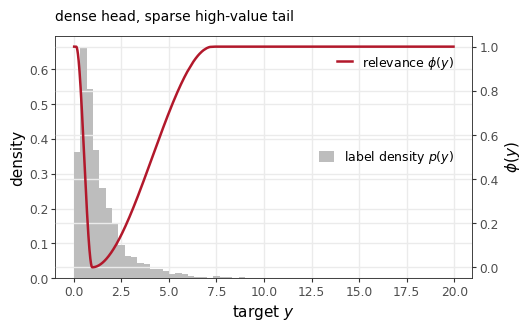

In [2]:
from MatImba.dataset.imba import calc_relevance, estimate_density

# A heavily right-skewed target — the typical shape of materials properties
y = np.exp(0.8 * rng.normal(size=4000) + 0.3 * rng.normal(size=4000))

rho = estimate_density(y, smooth="kde")   # density at each label
phi = calc_relevance(y, plot=False)       # tail relevance of each label

order = np.argsort(y)
fig, ax = plt.subplots(figsize=(5.2, 3.2), layout="compressed")
ax.hist(y, bins=60, density=True, color="#bdbdbd", label=r"label density $p(y)$")
ax_r = ax.twinx()
ax_r.plot(y[order], phi[order], color="#b2182b", lw=1.8, label=r"relevance $\phi(y)$")
ax_r.set_ylabel(r"$\phi(y)$")
ax.set_xlabel("target $y$")
ax.set_ylabel("density")
ax.grid(False)
ax_r.grid(False)
ax.legend(loc="center right", fontsize=9)
ax_r.legend(loc="upper right", fontsize=9)
ax.set_title("dense head, sparse high-value tail", fontsize=10)
plt.show()


### 1.2 Quantifying dataset imbalance: $h$, $G$, $D_{KL}$, $W_1$

Four bounded descriptors summarise a label vector *before training*:

- **$h$** (Distribution Imbalance Level) — a normalised Pietra ratio: the fraction of
  probability mass that must be redistributed to reach uniformity; scale-invariant,
  $h \in [0, 1]$.
- **$G$** (Gini) and **$D_{KL}$** (KL divergence from uniformity) — alternative
  statistical-magnitude measures.
- **$W_1$** (Wasserstein distance) — the *transport cost* of morphing the empirical
  CDF to uniform. Unlike the other three it is **not** permutation-invariant: it sees
  *where* in target space the mass sits, so it separates localised clustering
  (fragmented manifolds) from global skew.

A uniform sample scores near zero on all four; skew raises them together, while
manifold fragmentation raises $W_1$ disproportionately.


In [3]:
from MatImba.dataset.imba import calc_comprehensive_imbalance

for name, sample in {
    "uniform": rng.uniform(0, 1, 4000),
    "mild skew (gamma)": rng.gamma(4.0, size=4000),
    "heavy skew (lognormal)": y,
}.items():
    m = calc_comprehensive_imbalance(sample)
    print(f"{name:24s} h={m['DIL']:.3f}  G={m['Gini']:.3f}  "
          f"D_KL={m['KL_Div']:.3f}  W1={m['Wasserstein']:.3f}")


uniform                  h=0.030  G=0.037  D_KL=0.002  W1=0.004
mild skew (gamma)        h=0.550  G=0.652  D_KL=0.789  W1=0.278
heavy skew (lognormal)   h=0.759  G=0.870  D_KL=1.741  W1=0.430


### 1.3 Evaluating models: SERA and awareness $\alpha$

Global MAE hides tail failure. MatImba's evaluation layer rests on two quantities,
both available on every `PredictionSet`:

- **SERA** (squared error–relevance area): squared error restricted to samples with
  $\phi(y) > t$, integrated over $t \in [t_0, 1]$. It rewards accuracy *where it
  matters*. The integration bound is a package-wide constant, `SERA_T0 = 0.5` —
  SERA values are only comparable at the same $t_0$.
- **awareness** $\alpha = 1 - \mathrm{dCor}\big(\log|y-\hat y|,\ \rho(y)^{-1}\big)$:
  distance correlation between log-error and inverse density. $\alpha = 1$ means
  errors are independent of label rarity; $\alpha \to 0$ means errors track sparsity
  — the signature failure of ordinary least squares on skewed data.

Below, two synthetic "models" with the **same global MAE**: one spreads its error
evenly, the other is accurate in the bulk and fails in the tail.


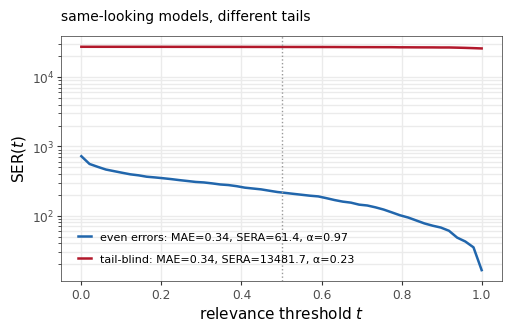

In [4]:
from MatImba.analysis import PredictionSet

noise = rng.normal(size=y.size)
even_model = PredictionSet(y, y + 0.30 * np.std(y) * noise,
                           relevances=phi, densities=rho, name="even errors")
scale = (1.0 / rho) / np.mean(1.0 / rho)      # error grows where data is sparse
tail_blind = PredictionSet(y, y + 0.30 * np.std(y) * noise * scale / scale.mean(),
                           relevances=phi, densities=rho, name="tail-blind")

fig, ax = plt.subplots(figsize=(5.0, 3.2), layout="compressed")
for ps, color in ((even_model, "#2166ac"), (tail_blind, "#b2182b")):
    ax.plot(ps.t_s, ps.sers, lw=1.8, color=color,
            label=f"{ps.name}: MAE={ps.mae:.2f}, SERA={ps.sera:.1f}, α={ps.alpha:.2f}")
ax.axvline(0.5, color="0.6", ls=":", lw=1)
ax.set_xlabel(r"relevance threshold $t$")
ax.set_ylabel("SER$(t)$")
ax.set_yscale("log")
ax.legend(fontsize=8)
ax.set_title("same-looking models, different tails", fontsize=10)
plt.show()


## 2. Stage 1 — Describe your dataset

`DatasetProfile` bundles everything above for a real label vector: $\rho$, $\phi$,
the four descriptors and the tail fraction. `compare_profiles` places several
datasets in a common *imbalance-metric space* (correlation matrix + PCA biplot) —
in the paper, PC1 is statistical imbalance magnitude and PC2 the geometric
transport cost.


In [5]:
from MatImba.analysis import DatasetProfile, compare_profiles

profiles = []
for name in ("log_gvrh", "phonons", "dielectric", "steels"):
    yv = pd.read_csv(f"matbench_data/{name}.csv").iloc[:, 0].dropna().values
    profiles.append(DatasetProfile(yv, name=name))

pd.DataFrame([p.metrics() for p in profiles]).set_index("name").round(3)


,n,h,Gini,D_KL,W1,tail_fraction
name,,,,,,
log_gvrh,10987,0.498,0.599,0.673,0.153,0.055
phonons,1265,0.631,0.742,1.062,0.354,0.051
dielectric,4764,0.909,0.967,3.107,0.477,0.090
steels,312,0.427,0.519,0.475,0.224,0.112


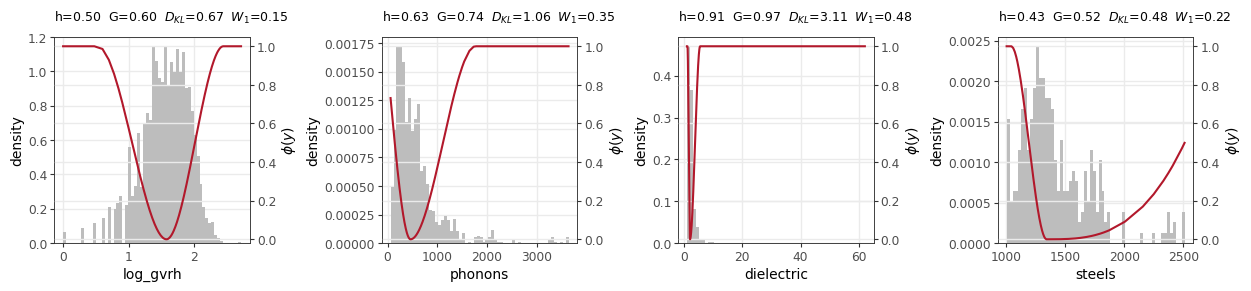

In [6]:
fig, axes = plt.subplots(1, len(profiles), figsize=(3.1 * len(profiles), 2.8),
                         layout="compressed")
for ax, prof in zip(axes, profiles):
    prof.plot(ax=ax)
plt.show()


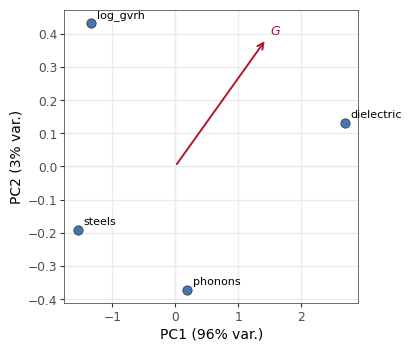

explained variance: [0.959 0.032]


,h,Gini,D_KL,W1
h,1.00,1.00,0.98,0.92
Gini,1.00,1.00,0.96,0.92
D_KL,0.98,0.96,1.00,0.89
W1,0.92,0.92,0.89,1.00


In [7]:
fig, ax = plt.subplots(figsize=(4.0, 3.4), layout="compressed")
result = compare_profiles(profiles, pca_ax=ax)
plt.show()
print("explained variance:", np.round(result["pca"]["explained_variance_ratio"], 3))
result["correlation"].round(2)


## 3. Stage 2 — Train robustly (with any PyTorch model)

The generic loop lives in `BaseRobustTrainer`:

- **DILA objective** (optional, `dil_inform=True`): adds
  $\lambda \cdot \mathrm{dCor}(\log|y-\hat y|,\ \rho^{-1})$ to the task loss with
  momentum-normalised statistics — actively *unlearning* density bias. Overhead: one
  distance-correlation evaluation per batch.
- **Accuracy-first robust checkpointing**: validation MAE is the primary criterion,
  with multiplicative penalties when $\alpha$ or SERA degrade — so you never select
  a checkpoint on the very metric you later report.
- **Five checkpoint flavours** (`best`, `r2_score_best`, `sera_best`, `dil_best`,
  last) and a per-epoch `val_log` CSV that Stage 3 consumes.

You implement two hooks: `forward_batch` (run the model) and `unpack_batch`
(return a `BatchFields` with `y`, and optionally `weights`/`density`/`relevance`).
The full recipe below is `examples/custom_trainer_example.py`, condensed.


In [8]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from MatImba.base_trainer import BaseRobustTrainer, BatchFields
from MatImba.dataset.imba import get_weights

torch.manual_seed(0)

# synthetic skewed problem: y driven by x[:, 0], log-normal tail
x = rng.normal(size=(2000, 8)).astype(np.float32)
yt = np.exp(0.8 * x[:, 0] + 0.3 * rng.normal(size=2000)).astype(np.float32)

density = estimate_density(yt, smooth="kde")
weights = get_weights(density, method="log_inv", eps=0.1)
relevance = calc_relevance(yt, plot=False)


def loader(sl, shuffle=False):
    ds = TensorDataset(torch.from_numpy(x[sl]), torch.from_numpy(yt[sl]),
                       torch.from_numpy(weights[sl].astype(np.float32)),
                       torch.from_numpy(density[sl].astype(np.float32)),
                       torch.from_numpy(relevance[sl].astype(np.float32)))
    return DataLoader(ds, batch_size=128, shuffle=shuffle)


class MLPTrainer(BaseRobustTrainer):
    def move_batch(self, batch):
        return [t.to(self.device) for t in batch]

    def forward_batch(self, batch):
        return self.model(batch[0])

    def unpack_batch(self, batch):
        _, yb, omega, rou, phi_b = batch
        return BatchFields(y=yb, weights=omega, density=rou, relevance=phi_b)


model = nn.Sequential(nn.Linear(8, 64), nn.SiLU(),
                      nn.Linear(64, 64), nn.SiLU(), nn.Linear(64, 1))
trainer = MLPTrainer(
    model=model,
    train_loader=loader(slice(0, 1400), shuffle=True),
    val_loader=loader(slice(1400, 1700)),
    test_loader=loader(slice(1700, 2000)),
    optimiser=torch.optim.AdamW(model.parameters(), lr=1e-3),
    scheduler_type="CosineAnnealingLR",
    epoch_range=30,
    dil_inform=True,                                       # enable DILA
    dil_config={"lambda": 1.0, "base_metric": "huber", "warmup_epochs": 5},
    name="guide_mlp_dila",
    outdir="guide_outputs",
)
results = trainer.fit()
results


Predicting:   0%|          | 0/3 [00:00<?, ?it/s]

{'test_mse': 0.523733792702357,
 'test_mae': 0.4744106920560201,
 'test_esr': 0.7060880661010742,
 'test_sera': 38.120452880859375,
 'test_scaled_error': 0.48553159832954407,
 'test_r2': 0.7736809253692627,
 'test_awareness': 0.5764187574386597}

For the paper's MEGNet graph-network pipeline the same loop is driven by yaml
configs:

```bash
matimba-train --cd expt_configs/final --cf log_kvrh_smooth_dila.yaml
```

Config suffixes select the objective: `_smooth_dila` (DILA) · `_dir` (Deep
Imbalanced Regression) · `_bsam` (Balanced Sharpness-Aware Minimisation) ·
none (Control).


## 4. Stage 3 — Analyse: from prediction files to a verdict

Everything in `MatImba.analysis` is **model-agnostic**: it consumes the
`*_test_predictions.csv` + `*_val_log.csv` files any trainer writes (or plain
arrays via `PredictionSet`). The archive layout is
`experiments/{set}/{dataset}/{method}/fold_{i}_run{j}_...`.

`collect_experiments` discovers runs, pairs prediction files with val_logs, and
screens exploded runs **within each fold** (`filter_bad_runs` — cross-fold $R^2$
comparison would wrongly drop runs evaluated on different test sets).


In [9]:
from MatImba.analysis import (aggregate, collect_experiments, coupling_table,
                              discovery_metrics, formatted_table, load_trajectories,
                              metrics_table, plot_alpha_sera, plot_budget_curves,
                              summary_plot)

index, preds = collect_experiments("experiments/matfold", datasets=["log_kvrh"])
print(index.groupby("method").size().rename("runs discovered"))

formatted_table(aggregate(metrics_table(preds)))   # ddof=1, sig-figure formatting


method
control        30
dir            25
smooth_dila    25
Name: runs discovered, dtype: int64


,dataset,method,mae,r2,sera,alpha,tail_mae,head_mae
0,log_kvrh,control,0.093 ± 0.005,0.830 ± 0.017,8 ± 5,0.66 ± 0.02,0.26 ± 0.04,0.085 ± 0.004
1,log_kvrh,dir,0.093 ± 0.005,0.834 ± 0.017,8 ± 4,0.67 ± 0.03,0.25 ± 0.04,0.085 ± 0.005
2,log_kvrh,smooth_dila,0.086 ± 0.004,0.843 ± 0.015,8 ± 4,0.66 ± 0.03,0.26 ± 0.03,0.078 ± 0.003


### 4.1 Error decomposition — *where* does a model fail?

`summary_plot` composes, per method: split parity with head/tail marginal KDEs
($\phi > 0.8$ defines the tail), SER curves, and a label-binned MAE profile pooled
over runs. Here for a single fold, method labels prettified.


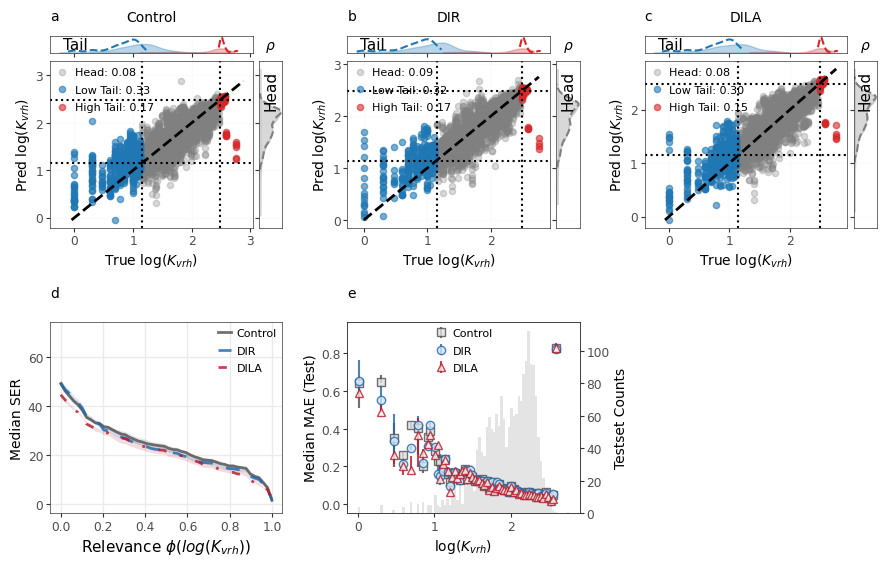

In [10]:
labels = {"control": "Control", "dir": "DIR", "smooth_dila": "DILA"}
groups = {labels[m]: [p for p in runs if p.name.startswith("fold_0_")]
          for m, runs in preds["log_kvrh"].items() if m in labels}
fig = summary_plot(groups, target_name=r"log($K_{vrh}$)")
plt.show()


### 4.2 Screening — does tail accuracy buy discoveries?

`discovery_metrics` simulates a virtual high-throughput screening campaign:
candidates with $\phi \geq$ `rel_threshold` are the targets, and the budget is
expressed in multiples of the true tail size. `plot_budget_curves` sweeps the
budget.


{'Discovery Mode': 'both', 'Tail Size (GT)': 9265, 'Budget Ratio': '1.0x (9265 tests)', 'Extrap. Precision': 0.7825, 'Tail Recall': 0.7825, 'Tail MAE': 0.1716, 'Breakdown': 'High=1595, Low=7670'}


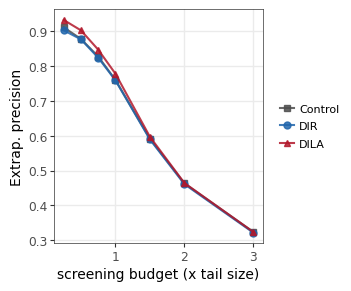

In [11]:
print(discovery_metrics(preds["log_kvrh"]["smooth_dila"], budget_ratio=1.0))

ax = plot_budget_curves(groups, metric="precision")
plt.show()


### 4.3 The coupling diagnosis — is tail error trainable away *at all*?

The platform's core deliverable. Pooling per-epoch $(\alpha, \mathrm{SERA})$ pairs
from the val_logs (25-epoch burn-in), `coupling_table` computes rank correlations
with bootstrap CIs and classifies each dataset × method into a **regime**:

| regime | meaning | implication |
|---|---|---|
| `linear` | SERA falls monotonically with $\alpha$ | awareness-based training (e.g. DILA) buys tail accuracy |
| `thresholded` | coupling only below a breakpoint | gains saturate once $\alpha$ is high |
| `decoupled` | no significant dependence | the tail-error floor is set by dataset geometry ($W_1$) — collect data, don't tune losses |

In the paper, moduli and phonon tasks are strongly linear ($\rho_s$ down to
$-0.7$) while perovskites is decoupled — which is exactly where no mitigation
method separates from the baseline.


In [12]:
traj = load_trajectories(index)
coupling_table(traj)[["dataset", "method", "n", "spearman", "spearman_p",
                      "regime"]].round(3)


,dataset,method,n,spearman,spearman_p,regime
0,log_kvrh,control,14250,-0.715,0.0,linear
1,log_kvrh,dir,11875,-0.616,0.0,linear
2,log_kvrh,smooth_dila,11875,-0.617,0.0,linear


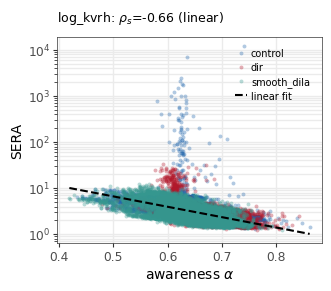

In [13]:
ax = plot_alpha_sera(traj, "log_kvrh")
plt.show()


## 5. Conventions, CLI and reproducibility

**Package-wide constants** (in `MatImba.analysis`) — change them nowhere else:

| constant | value | meaning |
|---|---|---|
| `SERA_T0` | 0.5 | SERA integration lower bound |
| `TAIL_PHI` | 0.8 | head/tail partition |
| `SCREEN_PHI` | 0.75 | screening candidates |

A cautionary tale: mixing archives evaluated at the legacy $t_0 = 0.8$ with runs at
$t_0 = 0.5$ made a baseline look four-fold better *purely from the convention* —
always recompute metrics from raw arrays when ingesting legacy files
(`PredictionSet(targets, preds, ...)` recomputes everything).

**Command line:**

```bash
matimba-train   --cd expt_configs/final --cf log_kvrh_smooth_dila.yaml   # Stage 2
matimba-analyse --experiments experiments/matfold --out figs/report      # Stage 3
```

**Reproducing the paper:** `python scripts/make_paper_figs.py --out figs/paper`
regenerates every figure and table from the archived predictions;
`Platform_figs.ipynb` (platform-story composites) and `Final_figs.ipynb`
(original figure set on the new data layer) are the interactive equivalents.

**Tests:** `pip install -e ".[dev]" && pytest tests/` — includes a full CPU
training run of the robust loop and regression tests for the metric layer.
